In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
customers = pd.read_csv("../data/tb_cust.csv")
transactions = pd.read_csv("../data/tb_transaction.csv")
products = pd.read_csv("../data/tb_transaction_product.csv")
fees = pd.read_csv("../data/tb_transaction_fees.csv")

In [24]:
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [25]:
total_customers = customers["customer_id"].nunique()

total_transactions = transactions["transaction_id"].nunique()

total_transaction_value = transactions["amount"].sum()

total_revenue = fees["fee_amount"].sum()

average_transaction = transactions["amount"].mean()

average_revenue_per_transaction = fees["fee_amount"].mean()

print(f"Total Customers: {total_customers:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Transaction Value: Rp {total_transaction_value:,.0f}")
print(f"Total Revenue: Rp {total_revenue:,.0f}")
print(f"Average Transaction: Rp {average_transaction:,.0f}")
print(
    f"Average Revenue per Transaction: "
    f"Rp {average_revenue_per_transaction:,.2f}"
)

Total Customers: 10,000
Total Transactions: 200,000
Total Transaction Value: Rp 61,506,712,597
Total Revenue: Rp 422,759,394
Average Transaction: Rp 307,534
Average Revenue per Transaction: Rp 2,113.80


In [26]:
active_users = (
    transactions["customer_id"]
    .nunique()
)

print(f"Active Users: {active_users:,}")

Active Users: 9,538


In [27]:
transactions["month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

monthly_active_users = (
    transactions
    .groupby("month")["customer_id"]
    .nunique()
    .reset_index(name="active_users")
)

monthly_active_users

,month,active_users
0,2025-01,5345
1,2025-02,5123
2,2025-03,5327
3,2025-04,5323
4,2025-05,5353
5,2025-06,5220
6,2025-07,5310
7,2025-08,5300
8,2025-09,5290
9,2025-10,5349


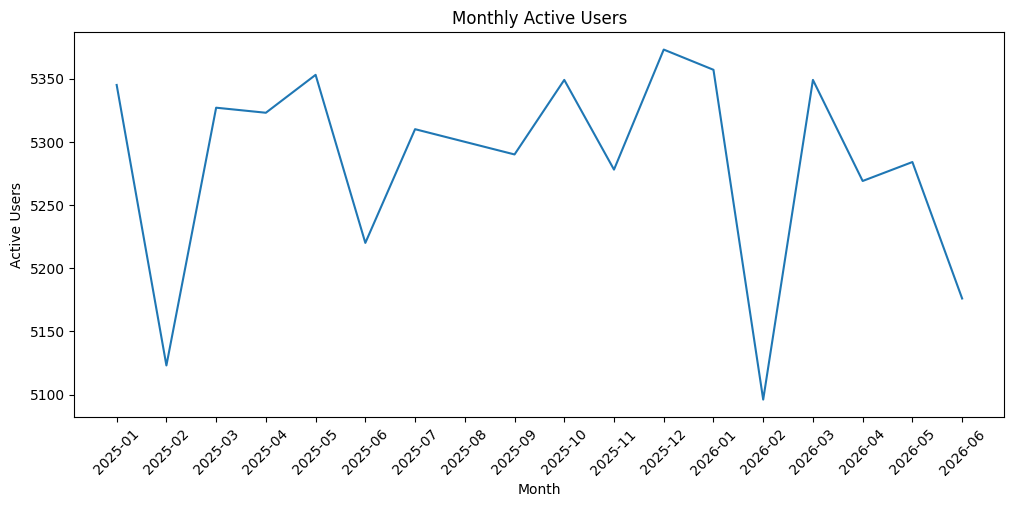

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_active_users["month"].astype(str),
    monthly_active_users["active_users"]
)

plt.title("Monthly Active Users")
plt.xlabel("Month")
plt.ylabel("Active Users")

plt.xticks(rotation=45)

plt.show()

In [29]:
transactions["date"] = (
    transactions["transaction_date"].dt.date
)

transactions["week"] = (
    transactions["transaction_date"]
    .dt.to_period("W")
)

In [30]:
dau = (
    transactions
    .groupby("date")["customer_id"]
    .nunique()
)

dau.head()

date
2025-01-01    343
2025-01-02    376
2025-01-03    363
2025-01-04    341
2025-01-05    352
Name: customer_id, dtype: int64

In [31]:
wau = (
    transactions
    .groupby("week")["customer_id"]
    .nunique()
)

wau.head()

week
2024-12-30/2025-01-05    1576
2025-01-06/2025-01-12    2059
2025-01-13/2025-01-19    2023
2025-01-20/2025-01-26    2059
2025-01-27/2025-02-02    2065
Freq: W-SUN, Name: customer_id, dtype: int64

In [32]:
mau = (
    transactions
    .groupby("month")["customer_id"]
    .nunique()
)

mau

month
2025-01    5345
2025-02    5123
2025-03    5327
2025-04    5323
2025-05    5353
2025-06    5220
2025-07    5310
2025-08    5300
2025-09    5290
2025-10    5349
2025-11    5278
2025-12    5373
2026-01    5357
2026-02    5096
2026-03    5349
2026-04    5269
2026-05    5284
2026-06    5176
Freq: M, Name: customer_id, dtype: int64

In [33]:
analysis_end_date = transactions["transaction_date"].max()

analysis_end_date

Timestamp('2026-06-30 00:00:00')

In [34]:
analysis_end_date = transactions["transaction_date"].max()

analysis_end_date

Timestamp('2026-06-30 00:00:00')

In [35]:
last_activity = (
    transactions
    .groupby("customer_id")["transaction_date"]
    .max()
    .reset_index(name="last_transaction_date")
)

In [36]:
customer_activity = customers.merge(
    last_activity,
    on="customer_id",
    how="left"
)

In [37]:
customer_activity["days_since_last_transaction"] = (
    analysis_end_date
    - customer_activity["last_transaction_date"]
).dt.days

In [38]:
inactive_90_days = customer_activity[
    customer_activity["days_since_last_transaction"] > 90
]

In [39]:
print(
    "Customers inactive > 90 days:",
    len(inactive_90_days)
)

Customers inactive > 90 days: 1872


In [40]:
inactive_rate = (
    len(inactive_90_days)
    / len(customer_activity)
    * 100
)

print(
    f"Inactive Rate (>90 days): {inactive_rate:.2f}%"
)

Inactive Rate (>90 days): 18.72%


In [41]:
revenue_data = transactions.merge(
    fees[
        [
            "transaction_id",
            "fee_percentage",
            "fee_amount"
        ]
    ],
    on="transaction_id",
    how="left"
)

In [42]:
transaction_volume = len(revenue_data)

In [43]:
transaction_value = revenue_data["amount"].sum()

In [44]:
revenue = revenue_data["fee_amount"].sum()

In [45]:
effective_fee_rate = (
    revenue / transaction_value
)

print(
    f"Effective Fee Rate: "
    f"{effective_fee_rate:.4%}"
)

Effective Fee Rate: 0.6873%


In [46]:
revenue_customer = revenue_data.merge(
    customers[
        [
            "customer_id",
            "customer_segment",
            "city"
        ]
    ],
    on="customer_id",
    how="left"
)

In [47]:
segment_revenue = (
    revenue_customer
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        revenue=("fee_amount", "sum")
    )
    .reset_index()
)

In [48]:
segment_revenue["revenue_contribution_pct"] = (
    segment_revenue["revenue"]
    / segment_revenue["revenue"].sum()
    * 100
)

In [49]:
segment_revenue

,customer_segment,customers,transactions,transaction_value,revenue,revenue_contribution_pct
0,College Student,3396,69646,2.142624e+10,1.470695e+08,34.787995
1,High School Student,2424,51832,1.585327e+10,1.091451e+08,25.817301
2,Office Worker,3718,78522,2.422720e+10,1.665448e+08,39.394704


In [50]:
type_performance = (
    revenue_customer
    .groupby("transaction_type")
    .agg(
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        revenue=("fee_amount", "sum")
    )
    .reset_index()
)

type_performance["revenue_contribution_pct"] = (
    type_performance["revenue"]
    / type_performance["revenue"].sum()
    * 100
)

type_performance

,transaction_type,transactions,transaction_value,revenue,revenue_contribution_pct
0,Bank Transfer,79797,3.846155e+10,1.923077e+08,45.488695
1,Shopping Payment,120203,2.304517e+10,2.304517e+08,54.511305
